In [25]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.5) # "talk"

ANIMATION=True
PLOT_FLUX=True

In [26]:
kappa=.05
NSTEPS=300000

DT_all=0.0125
Tend_all=0.3
mx=81

FLUX_TYPE=2

Flux_M=None
if(FLUX_TYPE==1):
    Flux_c=1.
    Flux_cv=np.zeros((1,mx))
    Flux_cv[:]=1.
    Flux_cv[0,3:int(mx/2.)-2]=2.
elif(FLUX_TYPE==2):
    nF=int(mx/2)
    shift=3

    Flux_cv=np.zeros((1,mx))
    Flux_M=np.zeros((1,mx))
    Flux_cv[0,:]=1.
    Flux_M[0,:]=1.
    Flux_cv[0,(0+shift):(nF-shift)]=2.
    Flux_M[0,(0+shift):(nF-shift)]=4.
elif(FLUX_TYPE==3):
    pass
else:
    error()

# Multirate A-stable

CFL max = 1.92375; CFL min = 1.0125
Solving AdvectionDiffusion1D by using MPRK2-IMEX2
Using a dt = 0.0125
Shape of u: (81, 25)
Kappa=0.05
Mass ini = 0.9999999999999999 and mass end = 0.9999999999999998; mass loss = -1.1102230246251565e-16


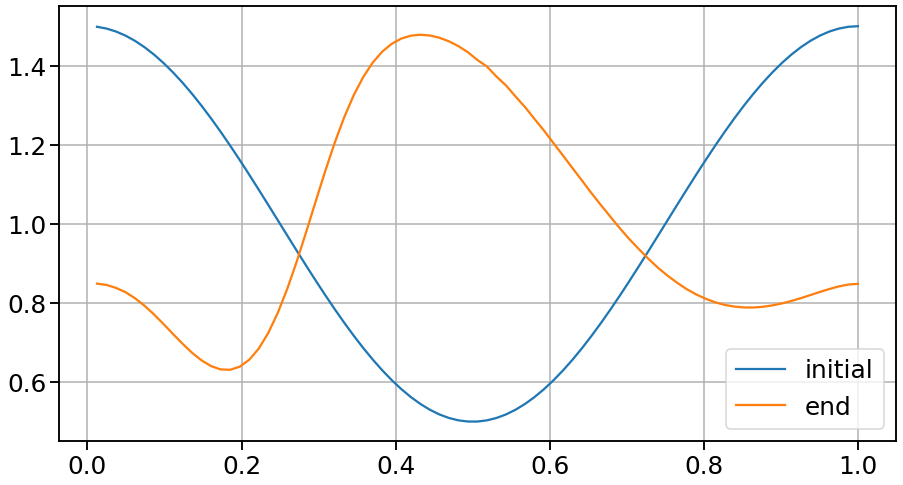

------------------------------------------
Current Method
Selected method type: IMEX-MRK
Method coefficients:
A_f =
[[0.   0.   0.   0.  ]
 [0.5  0.   0.   0.  ]
 [0.25 0.25 0.   0.  ]
 [0.25 0.25 0.5  0.  ]]
b_f =
[0.25 0.25 0.25 0.25]
c_f =
[0.  0.5 0.5 1. ]
A_s =
[[0. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 1. 0.]]
b_s =
[0.25 0.25 0.25 0.25]
c_s =
[0. 1. 0. 1.]
At =
[[0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.5 0.5 0.5]]
bt =
[0.25 0.25 0.25 0.25]
ct =
[0. 0. 0. 2.]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a2',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX',
 'MPRK2-m4-IMEX']

In [27]:
solver=None
solver=DESolver()
solver.set_info(0)


pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa,'Flux_name':'FVStagVanLeer-k=1/3'}



rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')

if(FLUX_TYPE==2):
    x_coord=problem_setup['context']['x_coord']
    #Flux_cv[0,(0):(nF)]=1.+np.sin(2*np.pi*x_coord[(0):(nF)])
    Flux_cv[0,(0):(nF)]=1.+0.9*np.exp(-((x_coord[(0):(nF)]-x_coord[nF//2-3])**2)*1.25*mx)
    Flux_M[0,(0):(nF)]=1.+2.9*np.exp(-((x_coord[(0):(nF)]-x_coord[nF//2-3])**2)*1.25*mx)
if(FLUX_TYPE==3):
    Flux_cv[0,:]=x_coord[:]

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_rhs(rhs_e)
solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow,'mr_implicit':problem.rhs_mr_implicit})
#solver.set_rhs({'imex_explicit':problem.rhs_e,'imex_implicit':problem.rhs_mr_implicit})
def rhs(t,y,ctx):
    x1,_=problem.rhs_e(t,y,ctx)
    x2,j2=problem.rhs_mr_implicit(t,y,ctx)
    return x1+x2, j2

#solver.set_rhs(rhs)
#solver.set_method('RK4')
solver.set_method('MPRK2-IMEX2')
#solver.set_method('MPRK2-RK3SSPHig-IMEX')
#solver.set_method('ARK2c')
#solver.set_method('ARK-IMEX-MR4-Slow')
#solver.set_method('ARK-IMEX-MR4')

#if(rhs_i is not None):
#    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
#else:
#    solver.set_rhs(rhs_e)
    
problem_setup['DT']=DT_all
problem_setup['T_DURATION']['end']=Tend_all
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],
                                              np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))
print('Using a dt = {:}'.format(problem_setup['DT']))

solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()
print("Kappa={:}".format(kappa))
print("Mass ini = {:} and mass end = {:}; mass loss = {:}".format(mass_ini,mass_end,(mass_end-mass_ini)))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 8))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()

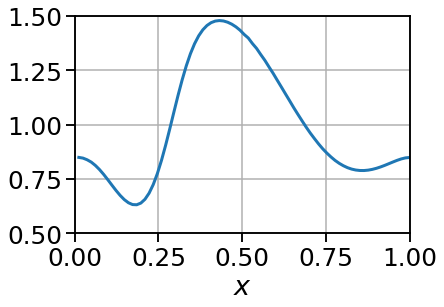

In [4]:
if(ANIMATION):
    fig = plt.figure()
    ax = plt.axes(xlim=(0, 1), ylim=(0.5, 1.5))
    line, = ax.plot([], [], lw=3)
    plt.grid('both')
    plt.xlabel(r'$x$')

    frames=u.shape[1]

    def init():
        line.set_data([], [])
        return line,
    def animate(i):
        x = x_coord
        y = np.squeeze(unvec(u[:,i],problem_setup['context']))
        line.set_data(x, y)
        return line,

    anim = FuncAnimation(fig, animate, init_func=init,
                                   frames=frames, interval=1, blit=True)


    anim.save('prk_imex2.gif', writer='imagemagick')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


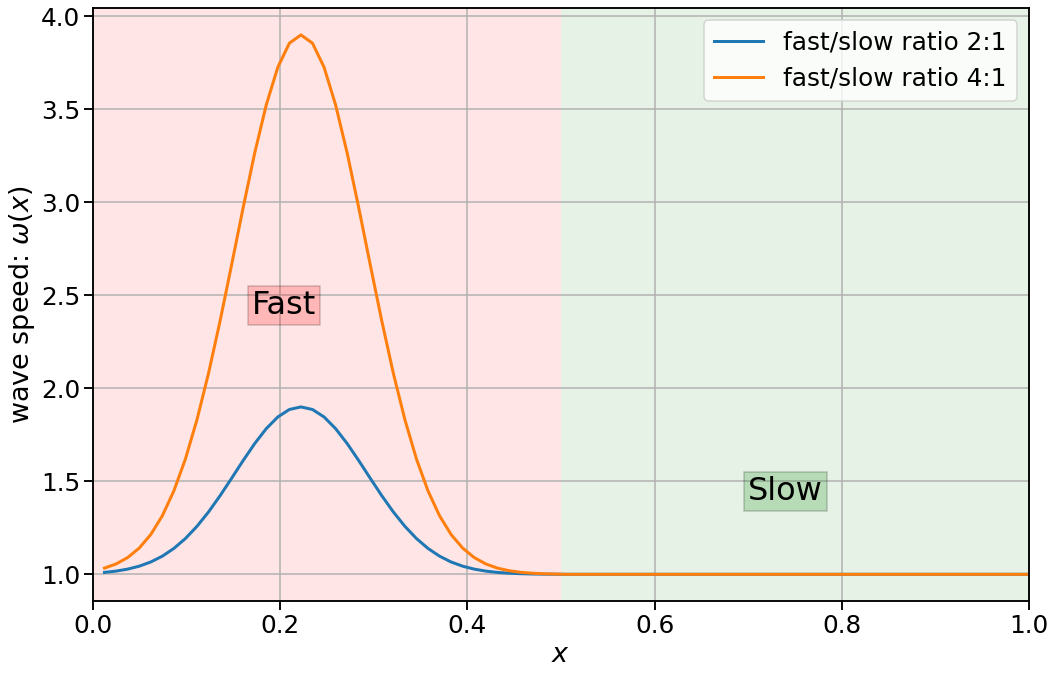

In [40]:
if(PLOT_FLUX):
    fig = plt.figure(figsize=(15, 10))
    plt.plot(x_coord,np.squeeze(Flux_cv),lw=3,label='fast/slow ratio 2:1')
    plt.plot(x_coord,np.squeeze(Flux_M),lw=3,label='fast/slow ratio 4:1')
    plt.xlabel(r'$x$')
    plt.ylabel(r'wave speed: $\omega(x)$')
    plt.grid('both')
    
    plt.legend()
    ax_list = fig.axes
    ax_list[0].axvspan(0, 0.5, facecolor='red', alpha=0.1)
    FS=32
    plt.text(0.17, 2.4, 'Fast', fontsize=FS,bbox=dict(facecolor='red', alpha=0.2))
    ax_list[0].axvspan(0.5, 1., facecolor='green', alpha=0.1)
    plt.text(0.7, 1.4, 'Slow', fontsize=FS,bbox=dict(facecolor='green', alpha=0.2))
    fig.tight_layout()
    plt.axis('tight')
    plt.xlim([0,1])
    plt.savefig('flux-function.png')
    plt.savefig('flux-function.eps')
    plt.show()

# Multirate - rate = 4

CFL max = 3.94875; CFL min = 1.0125
Solving AdvectionDiffusion1D by using MPRK2-m4-IMEX
Using a dt = 0.0125
Shape of u: (81, 25)
Kappa=0.05
Mass ini = 0.9999999999999999 and mass end = 1.0000000000000007; mass loss = 7.771561172376096e-16


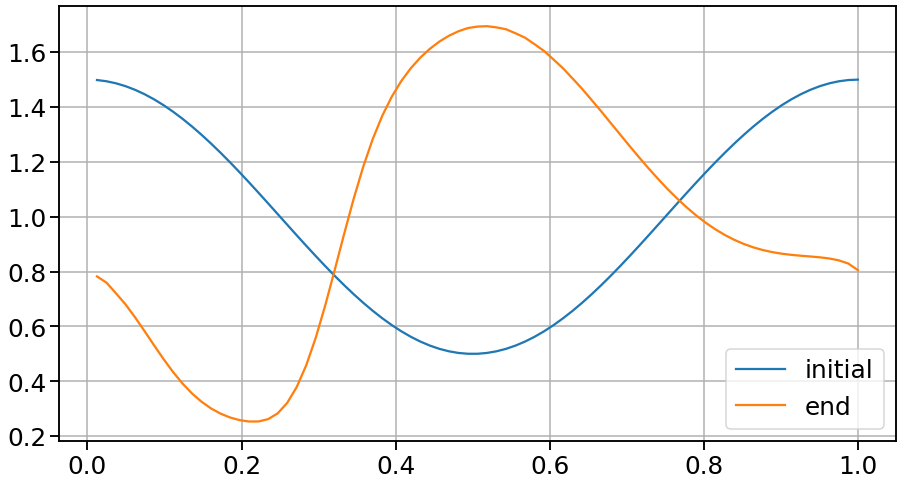

------------------------------------------
Current Method
Selected method type: IMEX-MRK
Method coefficients:
A_f =
[[0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.25  0.    0.    0.    0.    0.    0.    0.   ]
 [0.125 0.125 0.    0.    0.    0.    0.    0.   ]
 [0.125 0.125 0.25  0.    0.    0.    0.    0.   ]
 [0.125 0.125 0.125 0.125 0.    0.    0.    0.   ]
 [0.125 0.125 0.125 0.125 0.25  0.    0.    0.   ]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.    0.   ]
 [0.125 0.125 0.125 0.125 0.125 0.125 0.25  0.   ]]
b_f =
[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
c_f =
[0.   0.25 0.25 0.5  0.5  0.75 0.75 1.  ]
A_s =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]]
b_s =
[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
c_s =
[0. 1. 0. 1. 0. 1. 0. 1.]
At =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 

['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a2',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX',
 'MPRK2-m4-IMEX']

In [28]:
solver=None
solver=DESolver()
solver.set_info(0)


pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_M,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa,'Flux_name':'FVStagVanLeer-k=1/3'}



rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')

if(FLUX_TYPE==2):
    x_coord=problem_setup['context']['x_coord']
    #Flux_cv[0,(0):(nF)]=1.+np.sin(2*np.pi*x_coord[(0):(nF)])
    Flux_cv[0,(0):(nF)]=1.+0.9*np.exp(-((x_coord[(0):(nF)]-x_coord[nF//2-3])**2)*1.25*mx)
if(FLUX_TYPE==3):
    Flux_cv[0,:]=x_coord[:]

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_rhs(rhs_e)
solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow,'mr_implicit':problem.rhs_mr_implicit})
#solver.set_rhs({'imex_explicit':problem.rhs_e,'imex_implicit':problem.rhs_mr_implicit})
def rhs(t,y,ctx):
    x1,_=problem.rhs_e(t,y,ctx)
    x2,j2=problem.rhs_mr_implicit(t,y,ctx)
    return x1+x2, j2


solver.set_method('MPRK2-m4-IMEX')

    
problem_setup['DT']=DT_all
problem_setup['T_DURATION']['end']=Tend_all
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],
                                              np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))
print('Using a dt = {:}'.format(problem_setup['DT']))

solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()
print("Kappa={:}".format(kappa))
print("Mass ini = {:} and mass end = {:}; mass loss = {:}".format(mass_ini,mass_end,(mass_end-mass_ini)))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 8))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')

plt.show()

solver.view_complete_status()

# Single rate Explicit

CFL max = 1.92375; CFL min = 1.0125
Solving AdvectionDiffusion1D by using RK2a
Using a dt = 0.0125
Shape of u: (81, 25)
Kappa=0.05
Mass ini = 0.9999999999999999 and mass end = -3.961408125713217e+28; mass loss = -3.961408125713217e+28


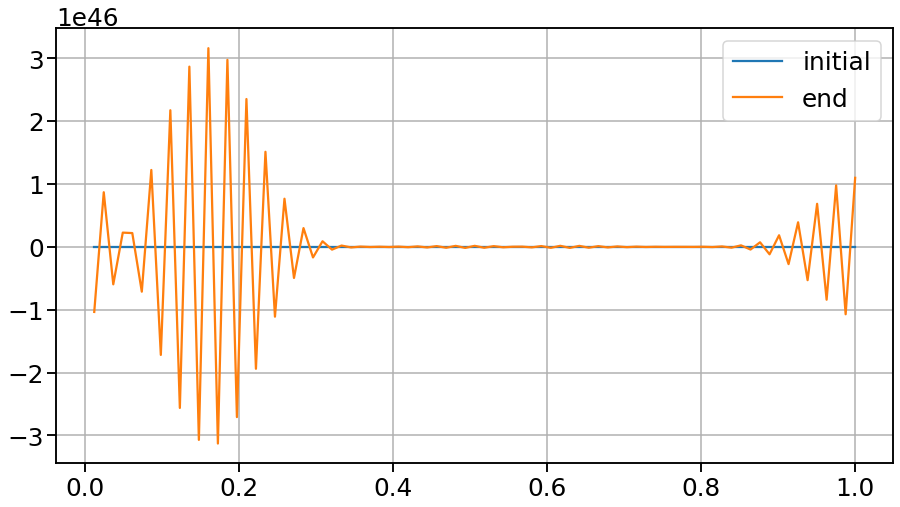

------------------------------------------
Current Method
Selected method type: RK
Method coefficients:
A =
[[0. 0.]
 [1. 0.]]
b =
[0.5 0.5]
c =
[0. 1.]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a2',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [6]:
solver=None
solver=DESolver()
solver.set_info(0)


pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa,'Flux_name':'FVStagVanLeer-k=1/3'}



rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')


solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
def rhs(t,y,ctx):
    x1,_=problem.rhs_e(t,y,ctx)
    x2,j2=problem.rhs_mr_implicit(t,y,ctx)
    return x1+x2, j2

solver.set_rhs(rhs)
solver.set_method('RK2a')
    
problem_setup['DT']=DT_all#*0.5
problem_setup['T_DURATION']['end']=Tend_all
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],
                                              np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))
print('Using a dt = {:}'.format(problem_setup['DT']))

solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()
print("Kappa={:}".format(kappa))
print("Mass ini = {:} and mass end = {:}; mass loss = {:}".format(mass_ini,mass_end,(mass_end-mass_ini)))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 8))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()

# Single rate Explicit (twice)

CFL max = 1.92375; CFL min = 1.0125
Solving AdvectionDiffusion1D by using RK2a2
Using a dt = 0.0125
Shape of u: (81, 25)
Kappa=0.05
Mass ini = 0.9999999999999999 and mass end = 2.440707734342608e+50; mass loss = 2.440707734342608e+50


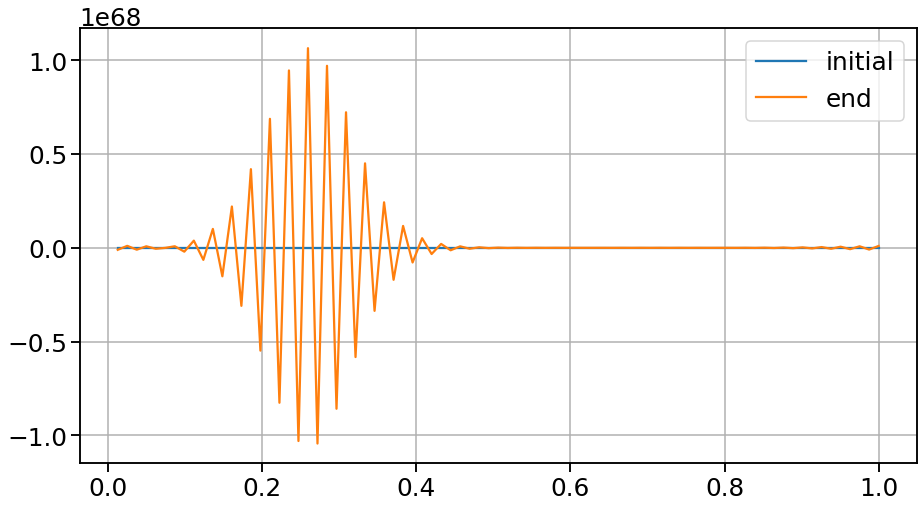

------------------------------------------
Current Method
Selected method type: RK
Method coefficients:
A =
[[0.   0.   0.   0.  ]
 [0.5  0.   0.   0.  ]
 [0.25 0.25 0.   0.  ]
 [0.25 0.25 0.5  0.  ]]
b =
[0.25 0.25 0.25 0.25]
c =
[0.  0.5 0.5 1. ]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a2',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [7]:
solver=None
solver=DESolver()
solver.set_info(0)


pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa,'Flux_name':'FVStagVanLeer-k=1/3'}



rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')


solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
def rhs(t,y,ctx):
    x1,_=problem.rhs_e(t,y,ctx)
    x2,j2=problem.rhs_mr_implicit(t,y,ctx)
    return x1+x2, j2

solver.set_rhs(rhs)
solver.set_method('RK2a2')
    
problem_setup['DT']=DT_all
problem_setup['T_DURATION']['end']=Tend_all
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],
                                              np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))
print('Using a dt = {:}'.format(problem_setup['DT']))

solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()
print("Kappa={:}".format(kappa))
print("Mass ini = {:} and mass end = {:}; mass loss = {:}".format(mass_ini,mass_end,(mass_end-mass_ini)))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 8))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()

# Multirate Explicit without Diffusion

CFL max = 1.92375; CFL min = 1.0125
Solving AdvectionDiffusion1D by using MPRK2
Using a dt = 0.0125
Shape of u: (81, 25)
Kappa=0.05
Mass ini = 0.9999999999999999 and mass end = 1.0000000000000002; mass loss = 3.3306690738754696e-16


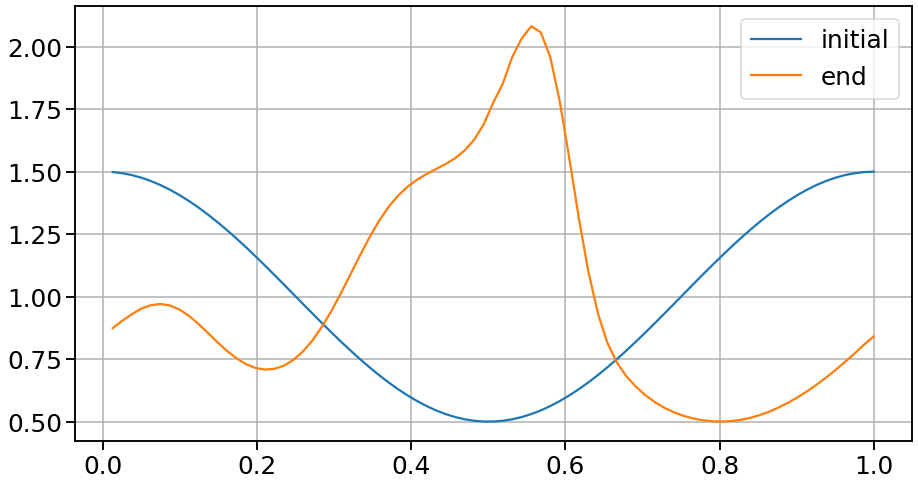

------------------------------------------
Current Method
Selected method type: MRK
Method coefficients:
A_f =
[[0.   0.   0.   0.  ]
 [0.5  0.   0.   0.  ]
 [0.25 0.25 0.   0.  ]
 [0.25 0.25 0.5  0.  ]]
b_f =
[0.25 0.25 0.25 0.25]
c_f =
[0.  0.5 0.5 1. ]
A_s =
[[0. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 1. 0.]]
b_s =
[0.25 0.25 0.25 0.25]
c_s =
[0. 1. 0. 1.]
A base =
[[0. 0.]
 [1. 0.]]
b base =
[0.5 0.5]
c base  =
[0. 1.]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a2',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [8]:
solver=None
solver=DESolver()
solver.set_info(0)


pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa,'Flux_name':'FVStagVanLeer-k=1/3'}



rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow})
solver.set_method('MPRK2')
#solver.set_method('MPRK2-RK3SSPHig')    
problem_setup['DT']=DT_all
problem_setup['T_DURATION']['end']=Tend_all
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],
                                              np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))
print('Using a dt = {:}'.format(problem_setup['DT']))

solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()
print("Kappa={:}".format(kappa))
print("Mass ini = {:} and mass end = {:}; mass loss = {:}".format(mass_ini,mass_end,(mass_end-mass_ini)))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 8))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()

# Single rate A-stable

CFL max = 0.961875; CFL min = 0.50625
Solving AdvectionDiffusion1D by using ARK-IMEX-MR2-AStable


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Shape of u: (81, 50)
Kappa=0.05
Mass ini = 0.9999999999999999 and mass end = 1.0; mass loss = 1.1102230246251565e-16


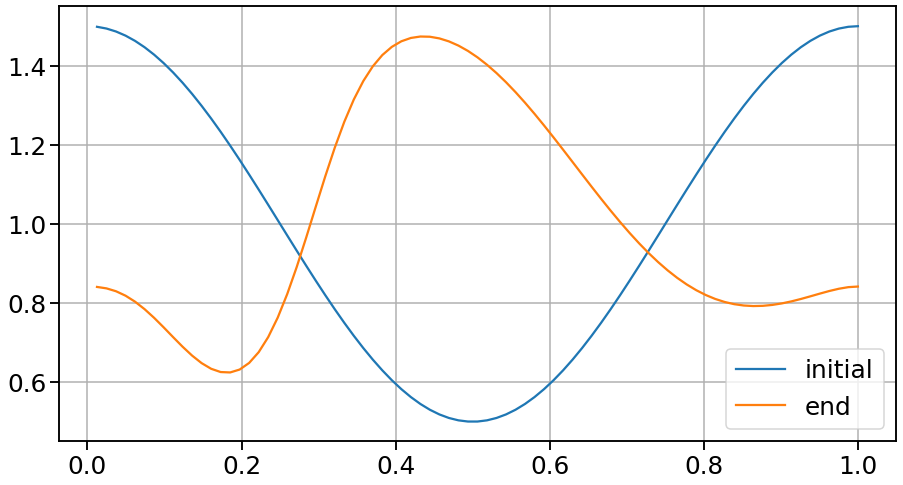

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0. 0.]
 [1. 0.]]
b =
[0.5 0.5]
c =
[0. 1.]
At =
[[0.  0. ]
 [0.5 0.5]]
bt =
[0.5 0.5]
ct =
[0. 1.]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a2',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [9]:
solver=None
solver=DESolver()
solver.set_info(0)


pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa,'Flux_name':'FVStagVanLeer-k=1/3'}



rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')


solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_rhs({'imex_explicit':problem.rhs_e,'imex_implicit':problem.rhs_mr_implicit})


solver.set_method('ARK-IMEX-MR2-AStable')
    
problem_setup['DT']=DT_all*0.5
problem_setup['T_DURATION']['end']=Tend_all
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],
                                              np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))


solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()
print("Kappa={:}".format(kappa))
print("Mass ini = {:} and mass end = {:}; mass loss = {:}".format(mass_ini,mass_end,(mass_end-mass_ini)))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 8))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()

# Multirate L-stable

CFL max = 1.92375; CFL min = 1.0125
Solving AdvectionDiffusion1D by using MPRK2-IMEX
Shape of u: (81, 25)
Kappa=0.05
Mass ini = 0.9999999999999999 and mass end = 0.9999999999999999; mass loss = 0.0


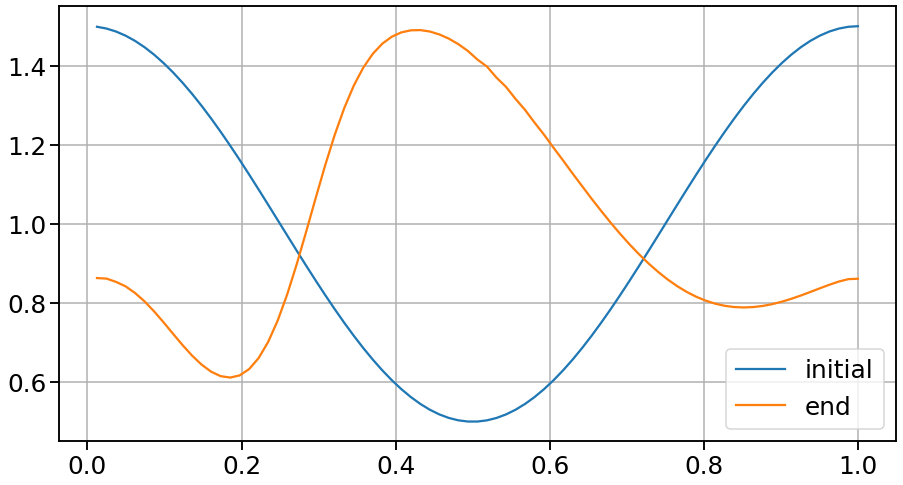

------------------------------------------
Current Method
Selected method type: IMEX-MRK
Method coefficients:
A_f =
[[0.   0.   0.   0.  ]
 [0.5  0.   0.   0.  ]
 [0.25 0.25 0.   0.  ]
 [0.25 0.25 0.5  0.  ]]
b_f =
[0.25 0.25 0.25 0.25]
c_f =
[0.  0.5 0.5 1. ]
A_s =
[[0. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 1. 0.]]
b_s =
[0.25 0.25 0.25 0.25]
c_s =
[0. 1. 0. 1.]
At =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [1. 1. 1. 1.]]
bt =
[0.25 0.25 0.25 0.25]
ct =
[0. 0. 0. 4.]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a2',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [10]:


solver=None
solver=DESolver()
solver.set_info(0)


pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa,'Flux_name':'FVStagVanLeer-k=1/3'}

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_rhs(rhs_e)
solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow,'mr_implicit':problem.rhs_mr_implicit})
#solver.set_rhs({'imex_explicit':problem.rhs_e,'imex_implicit':problem.rhs_mr_implicit})

#solver.set_method('RK4')
solver.set_method('MPRK2-IMEX')
#solver.set_method('MPRK2-RK3SSPHig-IMEX')
#solver.set_method('ARK2c')
#solver.set_method('ARK-IMEX-MR4-Slow')
#solver.set_method('ARK-IMEX-MR4')

#if(rhs_i is not None):
#    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
#else:
#    solver.set_rhs(rhs_e)
    
problem_setup['DT']=DT_all 
problem_setup['T_DURATION']['end']=Tend_all
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))


solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()
print("Kappa={:}".format(kappa))
print("Mass ini = {:} and mass end = {:}; mass loss = {:}".format(mass_ini,mass_end,(mass_end-mass_ini)))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 8))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()

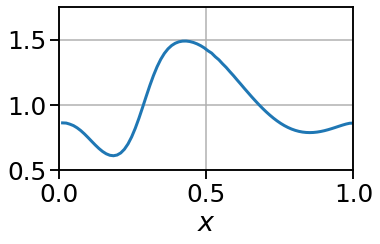

In [11]:
if(ANIMATION):
    fig = plt.figure()
    ax = plt.axes(xlim=(0, 1), ylim=(0.5, 1.75))
    line, = ax.plot([], [], lw=3)
    plt.grid('both')
    plt.xlabel(r'$x$')
    plt.tight_layout()
    frames=u.shape[1]

    def init():
        line.set_data([], [])
        return line,
    def animate(i):
        x = x_coord
        y = np.squeeze(unvec(u[:,i],problem_setup['context']))
        line.set_data(x, y)
        return line,

    anim = FuncAnimation(fig, animate, init_func=init,
                                   frames=frames, interval=1, blit=True)


    anim.save('prk_imex1.gif', writer='imagemagick')

CFL max = 0.192375; CFL min = 0.10125
Solving AdvectionDiffusion1D by using RK4
Using a dt = 0.0012500000000000002
Shape of u: (81, 242)
Kappa=0.05
Mass ini = 0.9999999999999999 and mass end = 1.0; mass loss = 1.1102230246251565e-16


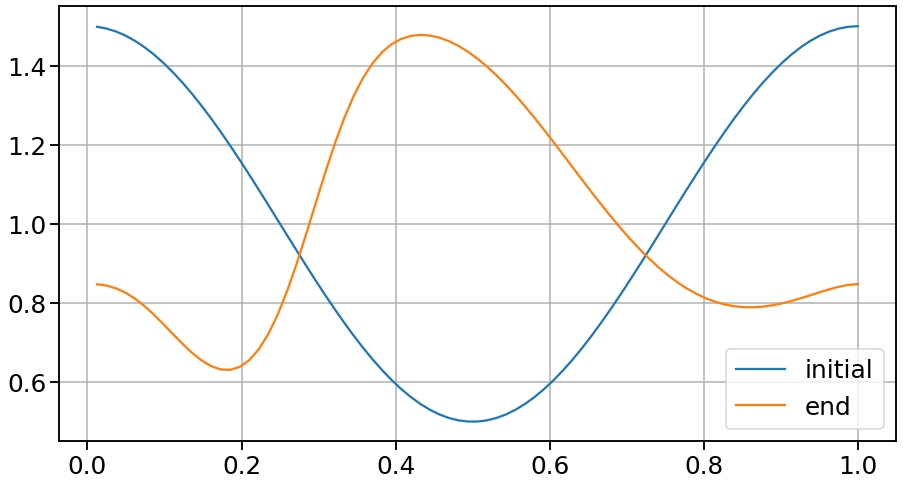

------------------------------------------
Current Method
Selected method type: RK
Method coefficients:
A =
[[0.  0.  0.  0. ]
 [0.5 0.  0.  0. ]
 [0.  0.5 0.  0. ]
 [0.  0.  1.  0. ]]
b =
[0.16666667 0.33333333 0.33333333 0.16666667]
c =
[0.  0.5 0.5 1. ]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a2',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [12]:
solver=None
solver=DESolver()
solver.set_info(0)


pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa,'Flux_name':'FVStagVanLeer-k=1/3'}



rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')


solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
def rhs(t,y,ctx):
    x1,_=problem.rhs_e(t,y,ctx)
    x2,j2=problem.rhs_mr_implicit(t,y,ctx)
    return x1+x2, j2

solver.set_rhs(rhs)
solver.set_method('RK4')
    
problem_setup['DT']=DT_all*0.1
problem_setup['T_DURATION']['end']=Tend_all
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],
                                              np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))
print('Using a dt = {:}'.format(problem_setup['DT']))

solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()
print("Kappa={:}".format(kappa))
print("Mass ini = {:} and mass end = {:}; mass loss = {:}".format(mass_ini,mass_end,(mass_end-mass_ini)))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 8))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()